In [1]:
import requests
import json
import os

In [2]:
# PID = 2310007901

In [3]:
payload = [{"productId":23100079}]

response = requests.post("https://www150.statcan.gc.ca/t1/wds/rest/getCubeMetadata", json=payload)

response.json()

[{'status': 'SUCCESS',
  'object': {'responseStatusCode': 0,
   'productId': '23100079',
   'cansimId': '401-0001',
   'cubeTitleEn': 'Operating and financial statistics for major Canadian airlines, monthly',
   'cubeTitleFr': "Statistiques d'exploitation et financières des principaux transporteurs aériens canadiens, mensuel",
   'cubeStartDate': '1981-01-01',
   'cubeEndDate': '2026-04-01',
   'frequencyCode': 6,
   'nbSeriesCube': 11,
   'nbDatapointsCube': 4676,
   'releaseTime': '2026-06-25T08:30',
   'archiveStatusCode': '2',
   'archiveStatusEn': 'CURRENT - a cube available to the public and that is current',
   'archiveStatusFr': 'ACTIF - un cube qui est disponible au public et qui est toujours mise a jour',
   'subjectCode': ['230105', '330305'],
   'surveyCode': ['5026'],
   'dimension': [{'dimensionPositionId': 1,
     'dimensionNameEn': 'Geography',
     'dimensionNameFr': 'Géographie',
     'hasUom': False,
     'member': [{'memberId': 1,
       'parentMemberId': None,
    

In [4]:
response = requests.get("https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/23100079/en")
data = response.json()["object"]

print(data)

https://www150.statcan.gc.ca/n1/tbl/csv/23100079-eng.zip


In [5]:
download_zip = requests.get(data)

In [6]:
import zipfile
import io

with zipfile.ZipFile(io.BytesIO(download_zip.content)) as z:

    z.extractall("../dataset")

# Analysis

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("../dataset/23100079.csv")
df

,REF_DATE,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.10,1895.0,NaN,NaN,NaN,0
1,1981-01,Canada,2021A000011124,Passenger-kilometres,Number,223,thousands,3,v11744,1.20,3411545.0,NaN,NaN,NaN,0
2,1981-01,Canada,2021A000011124,Kilograms of goods,Kilograms,192,thousands,3,v11745,1.30,29091.0,NaN,NaN,t,0
3,1981-01,Canada,2021A000011124,Goods tonne-kilometres,Tonne-kilometres,285,thousands,3,v11746,1.40,64084.0,NaN,NaN,t,0
4,1981-01,Canada,2021A000011124,Hours flown,Number,223,thousands,3,v11747,1.50,53.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4671,2026-04,Canada,2021A000011124,Available seat-kilometres,Number,223,thousands,3,v107645152,1.10,22986800.0,NaN,NaN,NaN,0
4672,2026-04,Canada,2021A000011124,Load factor,Percent,239,units,0,v107645153,1.11,84.8,NaN,NaN,NaN,1
4673,2026-04,Canada,2021A000011124,Hours flown,Number,223,thousands,3,v11747,1.50,185.0,NaN,NaN,NaN,0
4674,2026-04,Canada,2021A000011124,Turbo fuel consumed,Litres,203,thousands,3,v11748,1.60,630385.0,NaN,NaN,NaN,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4676 entries, 0 to 4675
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   REF_DATE                              4676 non-null   object 
 1   GEO                                   4676 non-null   object 
 2   DGUID                                 4676 non-null   object 
 3   Operational and financial statistics  4676 non-null   object 
 4   UOM                                   4676 non-null   object 
 5   UOM_ID                                4676 non-null   int64  
 6   SCALAR_FACTOR                         4676 non-null   object 
 7   SCALAR_ID                             4676 non-null   int64  
 8   VECTOR                                4676 non-null   object 
 9   COORDINATE                            4676 non-null   float64
 10  VALUE                                 4147 non-null   float64
 11  STATUS           

In [10]:
df = df[df["Operational and financial statistics"] == "Passengers"].reset_index(drop=True)
df

,REF_DATE,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1981-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1895.0,NaN,NaN,NaN,0
1,1981-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1852.0,NaN,NaN,NaN,0
2,1981-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2130.0,NaN,NaN,NaN,0
3,1981-04,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2083.0,NaN,NaN,NaN,0
4,1981-05,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2118.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,2025-12,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7282.0,NaN,NaN,NaN,0
540,2026-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6949.0,NaN,NaN,NaN,0
541,2026-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6599.0,NaN,NaN,NaN,0
542,2026-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7575.0,NaN,NaN,NaN,0


In [11]:
df["PASSENGERS"] = df["VALUE"]*1000
df

,REF_DATE,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS,PASSENGERS
0,1981-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1895.0,NaN,NaN,NaN,0,1895000.0
1,1981-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1852.0,NaN,NaN,NaN,0,1852000.0
2,1981-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2130.0,NaN,NaN,NaN,0,2130000.0
3,1981-04,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2083.0,NaN,NaN,NaN,0,2083000.0
4,1981-05,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2118.0,NaN,NaN,NaN,0,2118000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,2025-12,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7282.0,NaN,NaN,NaN,0,7282000.0
540,2026-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6949.0,NaN,NaN,NaN,0,6949000.0
541,2026-02,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6599.0,NaN,NaN,NaN,0,6599000.0
542,2026-03,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7575.0,NaN,NaN,NaN,0,7575000.0


In [14]:
df["REF_DATE"] = pd.to_datetime(df["REF_DATE"])
df = df.sort_values("REF_DATE")
df = df.set_index("REF_DATE")

In [15]:
df

,GEO,DGUID,Operational and financial statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS,PASSENGERS
REF_DATE,,,,,,,,,,,,,,,
1981-01-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1895.0,NaN,NaN,NaN,0,1895000.0
1981-02-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,1852.0,NaN,NaN,NaN,0,1852000.0
1981-03-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2130.0,NaN,NaN,NaN,0,2130000.0
1981-04-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2083.0,NaN,NaN,NaN,0,2083000.0
1981-05-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,2118.0,NaN,NaN,NaN,0,2118000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,7282.0,NaN,NaN,NaN,0,7282000.0
2026-01-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6949.0,NaN,NaN,NaN,0,6949000.0
2026-02-01,Canada,2021A000011124,Passengers,Number,223,thousands,3,v11743,1.1,6599.0,NaN,NaN,NaN,0,6599000.0


In [16]:
df.drop(['GEO', 'DGUID', 'UOM', 'UOM_ID', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS', 'Operational and financial statistics', 'SCALAR_FACTOR', 'VALUE'],  axis=1, inplace=True)

In [17]:
df

,PASSENGERS
REF_DATE,
1981-01-01,1895000.0
1981-02-01,1852000.0
1981-03-01,2130000.0
1981-04-01,2083000.0
1981-05-01,2118000.0
...,...
2025-12-01,7282000.0
2026-01-01,6949000.0
2026-02-01,6599000.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 544 entries, 1981-01-01 to 2026-04-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PASSENGERS  544 non-null    float64
dtypes: float64(1)
memory usage: 8.5 KB


In [19]:
df.isna().sum()

PASSENGERS    0
dtype: int64

In [20]:
df.index.is_monotonic_increasing

True

In [21]:
df["PASSENGERS"].describe()

count    5.440000e+02
mean     3.154877e+06
std      1.932101e+06
min      2.130000e+05
25%      1.831750e+06
50%      2.243000e+06
75%      3.529500e+06
max      8.463000e+06
Name: PASSENGERS, dtype: float64

In [29]:
df.tail()

,PASSENGERS
REF_DATE,
2025-12-01,7282000.0
2026-01-01,6949000.0
2026-02-01,6599000.0
2026-03-01,7575000.0
2026-04-01,7039000.0


# Visualization

In [22]:
import matplotlib.pyplot as plt

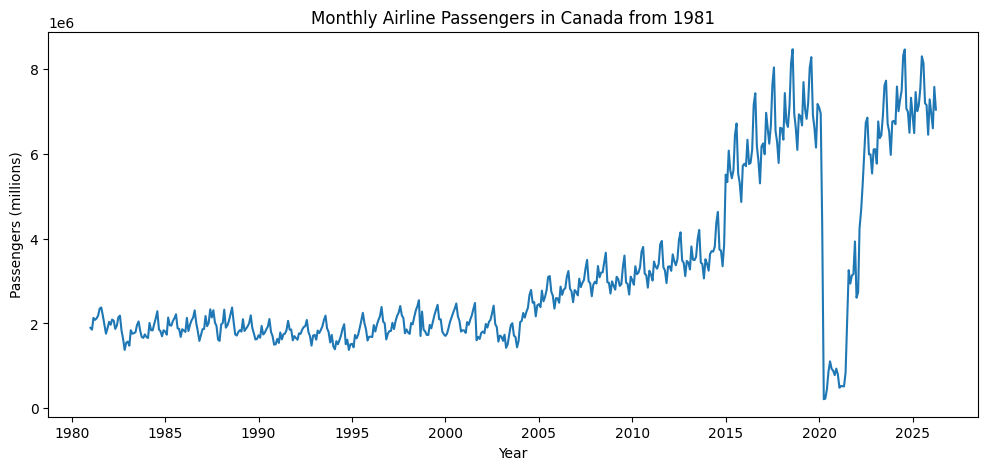

In [30]:
plt.figure(figsize= (12, 5))
plt.plot(df.index, df["PASSENGERS"])
plt.title("Monthly Airline Passengers in Canada from 1981")
plt.xlabel("Year")
plt.ylabel("Passengers (millions)")
plt.show()

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose

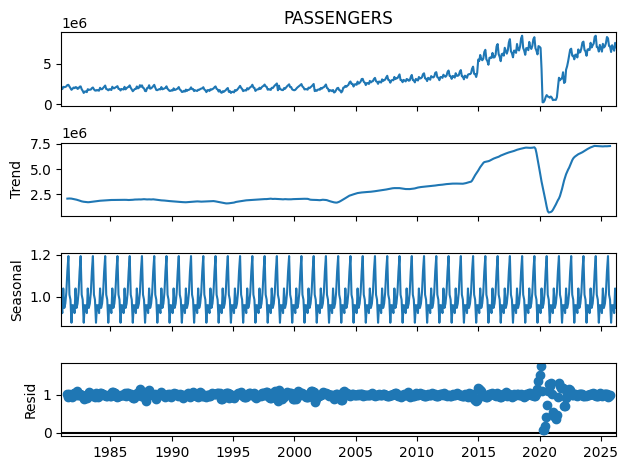

In [32]:
decompose = seasonal_decompose(df["PASSENGERS"], model="multiplicative", period=12)
decompose.plot()
plt.show()

In [33]:
from statsmodels.tsa.stattools import adfuller

In [34]:
adf_result = adfuller(df["PASSENGERS"])

print("ADF Statistics: ", adf_result[0])
print("p-value: ", adf_result[1])
print("Critical Values: ")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistics:  -1.6608223648304419
p-value:  0.4514025354617769
Critical Values: 
1%: -3.4428672600488066
5%: -2.8670609714890403
10%: -2.5697104770975057
